# UE23CS352A: Machine Learning — Week 6
# Artificial Neural Networks for Function Approximation

**Name:** Rachit S Mane  
**SRN:** `PES1UG24AM214`  
**Architecture:** `Input(1) → Hidden Layer 1 → Hidden Layer 2 → Output(1)`  
**Implementation:** fully from scratch in NumPy — no TensorFlow / PyTorch / Keras.

---

**Notebook structure**

* **Part A — Baseline model:** dataset generation from the SRN, ReLU + its derivative, MSE loss,
  Xavier initialization, forward propagation, backpropagation, the gradient-descent training loop,
  evaluation and the required plots.
* **Part B — Hyperparameter exploration:** four additional *fully executed* experiments
  (learning rate, batch size, number of epochs, activation function), each with its own
  training-loss curve and predicted-vs-actual plot, followed by the results comparison table.

> **Note on the results table.** This is a *regression* problem, so classification accuracy is not
> defined — the accuracy columns are reported as `N/A` and R² is given instead as the meaningful
> goodness-of-fit measure. The provided pipeline splits the data into **train (80%) / test (20%)
> only**; there is no separate validation split, so the validation columns are also `N/A`.
> The test set is what the training loop monitors for early stopping.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

##PART -A

In [2]:
STUDENT_ID = "PES1UG24AM214"

# AUTOMATIC ASSIGNMENT BASED ON SRN - DO NOT MODIFY

In [3]:
def get_student_assignment(student_id):
    """
    Generate unique polynomial TYPE and architecture based on student ID
    Uses last 3 digits of student ID for assignment
    """

    last_three = int(student_id[-3:])

    poly_type = last_three % 5

    np.random.seed(last_three)

    if poly_type == 0:
        degree = 2
        a = 0
        b = np.random.uniform(0.8, 1.5)
        c = np.random.uniform(3.0, 8.0)
        d = np.random.uniform(5.0, 15.0)
        poly_desc = f"QUADRATIC: y = {b:.2f}x² + {c:.2f}x + {d:.2f}"

    elif poly_type == 1:
        degree = 3
        a = np.random.uniform(1.8, 2.5)
        b = np.random.uniform(-1.2, 0.2)
        c = np.random.uniform(3.0, 6.0)
        d = np.random.uniform(8.0, 12.0)
        poly_desc = f"CUBIC: y = {a:.2f}x³ + {b:.2f}x² + {c:.2f}x + {d:.2f}"

    elif poly_type == 2:
        degree = 4
        a = np.random.uniform(0.008, 0.02)
        b = np.random.uniform(1.5, 2.2)
        c = np.random.uniform(-1.0, 0.5)
        d = np.random.uniform(2.0, 5.0)
        e = np.random.uniform(8.0, 12.0)
        poly_desc = f"QUARTIC: y = {a:.4f}x⁴ + {b:.2f}x³ + {c:.2f}x² + {d:.2f}x + {e:.2f}"
        coefficients = (a, b, c, d, e)

    elif poly_type == 3:
        degree = "sine"
        a = np.random.uniform(1.5, 2.8)
        b = np.random.uniform(-0.8, 0.8)
        c = np.random.uniform(3.0, 6.0)
        d = np.random.uniform(8.0, 12.0)
        freq = np.random.uniform(0.02, 0.05)
        amp = np.random.uniform(5.0, 15.0)
        poly_desc = f"CUBIC + SINE: y = {a:.2f}x³ + {b:.2f}x² + {c:.2f}x + {d:.2f} + {amp:.1f}*sin({freq:.3f}x)"
        coefficients = (a, b, c, d, freq, amp)

    else:
        degree = "inverse"
        a = np.random.uniform(1.8, 2.5)
        b = np.random.uniform(-1.0, 0.5)
        c = np.random.uniform(3.0, 6.0)
        d = np.random.uniform(8.0, 12.0)
        inv_coeff = np.random.uniform(50, 200)
        poly_desc = f"CUBIC + INVERSE: y = {a:.2f}x³ + {b:.2f}x² + {c:.2f}x + {d:.2f} + {inv_coeff:.1f}/x"
        coefficients = (a, b, c, d, inv_coeff)


    if poly_type in [0, 1]:
        coefficients = (a, b, c, d)


    noise_std = np.random.uniform(1.5, 2.5)


    arch_type = last_three % 4
    architectures = {
        0: {"hidden1": 64, "hidden2": 64, "lr": 0.001, "batch_desc": "Balanced Architecture"},
        1: {"hidden1": 32, "hidden2": 72, "lr": 0.005, "batch_desc": "Narrow-to-Wide Architecture"},
        2: {"hidden1": 72, "hidden2": 32, "lr": 0.001, "batch_desc": "Wide-to-Narrow Architecture"},
        3: {"hidden1": 96, "hidden2": 96, "lr": 0.003, "batch_desc": "Large Balanced Architecture"}
    }

    return {
        "polynomial_type": poly_type,
        "degree": degree,
        "coefficients": coefficients,
        "polynomial_desc": poly_desc,
        "noise_std": noise_std,
        "architecture": architectures[arch_type],
        "student_seed": last_three
    }

# Get your assignment
assignment = get_student_assignment(STUDENT_ID)
poly_type = assignment["polynomial_type"]
degree = assignment["degree"]
coefficients = assignment["coefficients"]
noise_std = assignment["noise_std"]
hidden1 = assignment["architecture"]["hidden1"]
hidden2 = assignment["architecture"]["hidden2"]
learning_rate = assignment["architecture"]["lr"]

print("="*70)
print(f"ASSIGNMENT FOR STUDENT ID: {STUDENT_ID}")
print("="*70)
print(f"Polynomial Type: {assignment['polynomial_desc']}")
print(f"Noise Level: ε ~ N(0, {noise_std:.2f})")
print(f"Architecture: Input(1) → Hidden({hidden1}) → Hidden({hidden2}) → Output(1)")
print(f"Learning Rate: {learning_rate}")
print(f"Architecture Type: {assignment['architecture']['batch_desc']}")
print("="*70)


ASSIGNMENT FOR STUDENT ID: PES1UG24AM214
Polynomial Type: CUBIC + INVERSE: y = 1.83x³ + -0.47x² + 5.73x + 9.62 + 89.1/x
Noise Level: ε ~ N(0, 1.60)
Architecture: Input(1) → Hidden(72) → Hidden(32) → Output(1)
Learning Rate: 0.001
Architecture Type: Wide-to-Narrow Architecture


# DATASET GENERATION - DO NOT MODIFY

In [4]:
np.random.seed(assignment["student_seed"])

n_samples = 100000
x = np.random.uniform(-100, 100, n_samples)


if poly_type == 0:
    _, b, c, d = coefficients
    y = b * x**2 + c * x + d + np.random.normal(0, noise_std, n_samples)

elif poly_type == 1:
    a, b, c, d = coefficients
    y = a * x**3 + b * x**2 + c * x + d + np.random.normal(0, noise_std, n_samples)

elif poly_type == 2:
    a, b, c, d, e = coefficients
    y = a * x**4 + b * x**3 + c * x**2 + d * x + e + np.random.normal(0, noise_std, n_samples)

elif poly_type == 3:
    a, b, c, d, freq, amp = coefficients
    y = a * x**3 + b * x**2 + c * x + d + amp * np.sin(freq * x) + np.random.normal(0, noise_std, n_samples)

else:
    a, b, c, d, inv_coeff = coefficients

    y = a * x**3 + b * x**2 + c * x + d + inv_coeff / (x + np.sign(x) * 0.1) + np.random.normal(0, noise_std, n_samples)


df = pd.DataFrame({'x': x, 'y': y})
df.to_csv('student_polynomial_dataset.csv', index=False)
print(f"Dataset with {n_samples:,} samples generated and saved!")

X = df['x'].values.reshape(-1, 1)
Y = df['y'].values.reshape(-1, 1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)

print(f"Training samples: {len(X_train_scaled):,}")
print(f"Test samples: {len(X_test_scaled):,}")

Dataset with 100,000 samples generated and saved!
Training samples: 80,000
Test samples: 20,000


# ACTIVATION FUNCTIONS — ReLU and its derivative

In [5]:
def relu(z):
    """
    ReLU activation function.
        f(z) = max(0, z)
    Outputs 0 for negative inputs and the input itself for positive inputs.
    """
    return np.maximum(0, z)


def relu_derivative(z):
    """
    Derivative of the ReLU activation function.
        f'(z) = 1  if z > 0
        f'(z) = 0  if z <= 0
    Used during backpropagation to propagate the gradient through the
    hidden layers.
    """
    return (z > 0).astype(float)

# LOSS FUNCTION — Mean Squared Error

In [6]:
def mse_loss(y_true, y_pred):
    """
    Mean Squared Error loss.
        MSE = (1/m) * sum( (y_true - y_pred)^2 )
    Averages the squared differences between the true targets and the
    network predictions, penalising larger errors more heavily.
    """
    return np.mean((y_true - y_pred) ** 2)

# WEIGHT INITIALIZATION — XAVIER INITIALIZATION
## **Xavier (Glorot) Initialization**

When training neural networks, how we initialize weights matters.  
- If weights are **too small** → activations and gradients vanish.  
- If weights are **too large** → activations and gradients explode.  

#**Xavier initialization** (Glorot & Bengio, 2010) balances this by keeping the variance of activations roughly the same across all layers.

---

### Formula

Let:  
- **fan_in** = number of input units to a layer  
- **fan_out** = number of output units from a layer  

The variance of weights is:

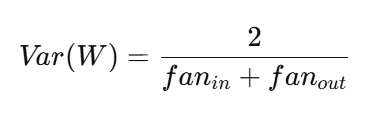


##Two common forms:  

#**Normal distribution:**  
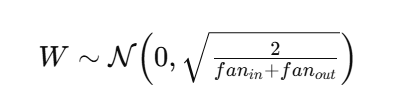

#**Uniform distribution:**  
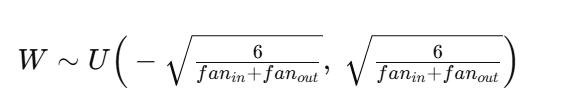

Biases are initialized to **0**.

---

### In This Assignment
- **W1 (input → hidden1):** `fan_in = input_dim`, `fan_out = hidden1`  
- **W2 (hidden1 → hidden2):** `fan_in = hidden1`, `fan_out = hidden2`  
- **W3 (hidden2 → output):** `fan_in = hidden2`, `fan_out = output_dim`  

Implemented below: `xavier_std` is computed per layer, weights are sampled from a normal distribution with that std, and biases are set to 0.



In [7]:
def xavier_initialization(input_dim, hidden1, hidden2, output_dim):
    """
    XAVIER (GLOROT) WEIGHT INITIALIZATION

    Xavier initialization: weights ~ N(0, sqrt(2/(fan_in + fan_out)))
    Biases are initialized to zeros.

    Args:
        input_dim: Size of input layer (1)
        hidden1: Size of first hidden layer
        hidden2: Size of second hidden layer
        output_dim: Size of output layer (1)

    Returns:
        W1, b1, W2, b2, W3, b3: Initialized weights and biases
    """
    np.random.seed(assignment["student_seed"])

    # Xavier standard deviation for each layer: sqrt(2 / (fan_in + fan_out))
    xavier_std_1 = np.sqrt(2.0 / (input_dim + hidden1))
    xavier_std_2 = np.sqrt(2.0 / (hidden1 + hidden2))
    xavier_std_3 = np.sqrt(2.0 / (hidden2 + output_dim))

    # W1: input -> first hidden layer
    W1 = np.random.normal(0.0, xavier_std_1, size=(input_dim, hidden1))
    b1 = np.zeros((1, hidden1))

    # W2: first hidden -> second hidden layer
    W2 = np.random.normal(0.0, xavier_std_2, size=(hidden1, hidden2))
    b2 = np.zeros((1, hidden2))

    # W3: second hidden -> output layer
    W3 = np.random.normal(0.0, xavier_std_3, size=(hidden2, output_dim))
    b3 = np.zeros((1, output_dim))

    return W1, b1, W2, b2, W3, b3

# FORWARD PROPAGATION

In [8]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    """
    FORWARD PROPAGATION

    Perform forward pass through the network:
    Input -> Hidden1(ReLU) -> Hidden2(ReLU) -> Output(Linear)

    Args:
        X: Input data (batch_size, 1)
        W1, b1: First layer weights and biases
        W2, b2: Second layer weights and biases
        W3, b3: Output layer weights and biases

    Returns:
        z1, a1, z2, a2, z3: Pre-activations and activations for each layer
    """

    # First hidden layer
    z1 = X @ W1 + b1
    a1 = relu(z1)

    # Second hidden layer
    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    # Output layer (linear activation - this is a regression problem)
    z3 = a2 @ W3 + b3

    return z1, a1, z2, a2, z3

# BACKWARD PROPAGATION

In [9]:
def backward_pass(X, Y_true, z1, a1, z2, a2, Y_pred, W2, W3):
    """
    BACKPROPAGATION

    Compute gradients using the chain rule:
    dLoss/dW = dLoss/dY_pred * dY_pred/dz * dz/dW

    Args:
        X: Input data
        Y_true: True target values
        z1, a1, z2, a2: Forward pass intermediate values
        Y_pred: Network predictions (z3)
        W2, W3: Weights (needed for gradient computation)

    Returns:
        dW1, db1, dW2, db2, dW3, db3: Gradients for all parameters
    """

    m = len(X)  # Batch size

    # Output layer: derivative of MSE w.r.t. the predictions
    # d/dY_pred [ (1/m) * sum((Y_true - Y_pred)^2) ] = (2/m) * (Y_pred - Y_true)
    dY_pred = (2.0 / m) * (Y_pred - Y_true)

    # Third layer (output) gradients - output activation is linear, so dz3 = dY_pred
    dW3 = a2.T @ dY_pred
    db3 = np.sum(dY_pred, axis=0, keepdims=True)

    # Second hidden layer gradients
    da2 = dY_pred @ W3.T
    dz2 = da2 * relu_derivative(z2)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # First hidden layer gradients
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_derivative(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

# TRAINING FUNCTION — full-batch gradient descent with early stopping

In [10]:
def train_neural_network(X_train, Y_train, X_test, Y_test, epochs=200, patience=10):
    """
    TRAINING LOOP (BASELINE)

    Full-batch gradient descent with early stopping, tracking the loss history.

    Args:
        X_train, Y_train: Training data
        X_test, Y_test: Test data used for monitoring / early stopping
        epochs: Maximum number of training epochs
        patience: Early stopping patience

    Returns:
        best_weights: Best model weights
        train_losses: Training loss history
        test_losses: Test loss history
    """


    W1, b1, W2, b2, W3, b3 = xavier_initialization(1, hidden1, hidden2, 1)

    best_test_loss = float('inf')
    best_weights = None
    patience_counter = 0

    train_losses = []
    test_losses = []

    print("Starting training...")
    print(f"Architecture: 1 → {hidden1} → {hidden2} → 1")
    print(f"Learning Rate: {learning_rate}")
    print(f"Max Epochs: {epochs}, Early Stopping Patience: {patience}")
    print("-" * 50)

    for epoch in range(epochs):


        z1, a1, z2, a2, Y_pred_train = forward_pass(X_train, W1, b1, W2, b2, W3, b3)


        train_loss = mse_loss(Y_train, Y_pred_train)


        dW1, db1, dW2, db2, dW3, db3 = backward_pass(X_train, Y_train, z1, a1, z2, a2, Y_pred_train, W2, W3)


        # Gradient descent update: parameter = parameter - learning_rate * gradient
        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1
        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2
        W3 = W3 - learning_rate * dW3
        b3 = b3 - learning_rate * db3


        _, _, _, _, Y_pred_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)
        test_loss = mse_loss(Y_test, Y_pred_test)


        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}: Train Loss = {train_loss:.6f}, Test Loss = {test_loss:.6f}")

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_weights = (W1.copy(), b1.copy(), W2.copy(), b2.copy(), W3.copy(), b3.copy())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            print(f"Best test loss: {best_test_loss:.6f}")
            break

    return best_weights, train_losses, test_losses

# EXECUTE TRAINING

In [11]:
print("Training Neural Network with your specific configuration...")
weights, train_losses, test_losses = train_neural_network(
    X_train_scaled, Y_train_scaled, X_test_scaled, Y_test_scaled,
    epochs=500, patience=10
)

Training Neural Network with your specific configuration...
Starting training...
Architecture: 1 → 72 → 32 → 1
Learning Rate: 0.001
Max Epochs: 500, Early Stopping Patience: 10
--------------------------------------------------


Epoch  20: Train Loss = 1.029698, Test Loss = 1.008999


Epoch  40: Train Loss = 0.988681, Test Loss = 0.968862


Epoch  60: Train Loss = 0.950262, Test Loss = 0.931273


Epoch  80: Train Loss = 0.913882, Test Loss = 0.895616


...

Epoch 420: Train Loss = 0.473670, Test Loss = 0.464304


Epoch 440: Train Loss = 0.455837, Test Loss = 0.446854


Epoch 460: Train Loss = 0.438874, Test Loss = 0.430264


Epoch 480: Train Loss = 0.422779, Test Loss = 0.414529


Epoch 500: Train Loss = 0.407544, Test Loss = 0.399644


# RESULTS VISUALIZATION

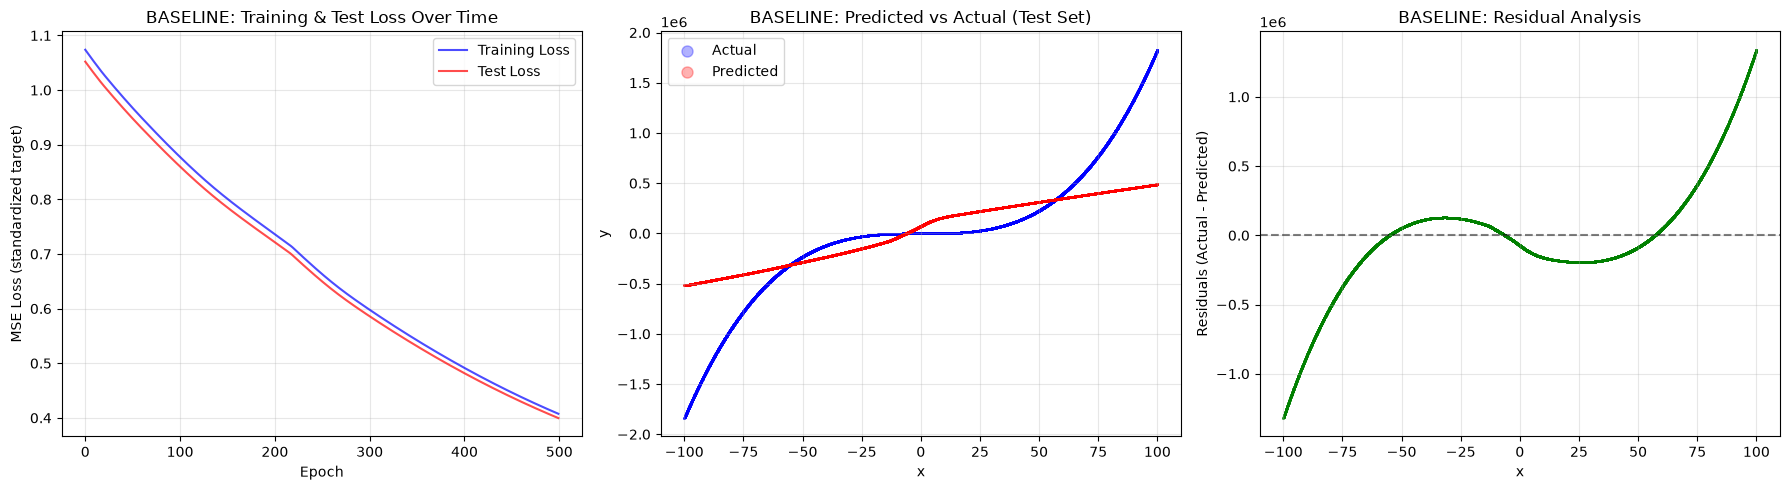

In [12]:
# Plot training progress (BASELINE)
plt.figure(figsize=(18, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss', color='blue', alpha=0.7)
plt.plot(test_losses, label='Test Loss', color='red', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (standardized target)')
plt.title('BASELINE: Training & Test Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

# Get final predictions for visualization
W1, b1, W2, b2, W3, b3 = weights
_, _, _, _, Y_pred_scaled = forward_pass(X_test_scaled, W1, b1, W2, b2, W3, b3)

# Inverse transform to original scale
Y_test_orig = scaler_Y.inverse_transform(Y_test_scaled)
Y_pred_orig = scaler_Y.inverse_transform(Y_pred_scaled)
X_test_orig = scaler_X.inverse_transform(X_test_scaled)

# Predictions vs Actual
plt.subplot(1, 3, 2)
plt.scatter(X_test_orig, Y_test_orig, s=1, alpha=0.3, label='Actual', color='blue')
plt.scatter(X_test_orig, Y_pred_orig, s=1, alpha=0.3, label='Predicted', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('BASELINE: Predicted vs Actual (Test Set)')
plt.legend(markerscale=8)
plt.grid(True, alpha=0.3)

# Residual plot
plt.subplot(1, 3, 3)
residuals = Y_test_orig.flatten() - Y_pred_orig.flatten()
plt.scatter(X_test_orig, residuals, s=1, alpha=0.3, color='green')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('BASELINE: Residual Analysis')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SPECIFIC PREDICTION TEST

In [13]:

x_test_value = 90.2
x_new = np.array([[x_test_value]])
x_new_scaled = scaler_X.transform(x_new)

_, _, _, _, y_pred_scaled = forward_pass(x_new_scaled, W1, b1, W2, b2, W3, b3)
y_pred = scaler_Y.inverse_transform(y_pred_scaled)

if poly_type == 0:
    _, b, c, d = coefficients
    y_true = b * x_test_value**2 + c * x_test_value + d

elif poly_type == 1:
    a, b, c, d = coefficients
    y_true = a * x_test_value**3 + b * x_test_value**2 + c * x_test_value + d

elif poly_type == 2:
    a, b, c, d, e = coefficients
    y_true = a * x_test_value**4 + b * x_test_value**3 + c * x_test_value**2 + d * x_test_value + e

elif poly_type == 3:
    a, b, c, d, freq, amp = coefficients
    y_true = a * x_test_value**3 + b * x_test_value**2 + c * x_test_value + d + amp * np.sin(freq * x_test_value)

else:
    a, b, c, d, inv_coeff = coefficients
    y_true = a * x_test_value**3 + b * x_test_value**2 + c * x_test_value + d + inv_coeff / (x_test_value + np.sign(x_test_value) * 0.1)

print("\n" + "="*60)
print("PREDICTION RESULTS FOR x = 90.2")
print("="*60)
print(f"Neural Network Prediction: {y_pred[0][0]:,.2f}")
print(f"Ground Truth (formula):    {y_true:,.2f}")
print(f"Absolute Error:            {abs(y_pred[0][0] - y_true):,.2f}")
print(f"Relative Error:            {abs(y_pred[0][0] - y_true)/abs(y_true)*100:.3f}%")




PREDICTION RESULTS FOR x = 90.2
Neural Network Prediction: 454,817.10
Ground Truth (formula):    1,342,483.50
Absolute Error:            887,666.40
Relative Error:            66.121%


# PERFORMANCE METRICS

In [14]:
# Calculate final performance metrics
final_train_loss = train_losses[-1] if train_losses else float('inf')
final_test_loss = test_losses[-1] if test_losses else float('inf')

# Calculate R² score
y_test_mean = np.mean(Y_test_orig)
ss_res = np.sum((Y_test_orig - Y_pred_orig) ** 2)
ss_tot = np.sum((Y_test_orig - y_test_mean) ** 2)
r2_score = 1 - (ss_res / ss_tot)

print("\n" + "="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)
print(f"Final Training Loss: {final_train_loss:.6f}")
print(f"Final Test Loss:     {final_test_loss:.6f}")
print(f"R² Score:           {r2_score:.4f}")
print(f"Total Epochs Run:   {len(train_losses)}")


FINAL PERFORMANCE SUMMARY
Final Training Loss: 0.407544
Final Test Loss:     0.399644
R² Score:           0.5936
Total Epochs Run:   500


---
# PART B — Hyperparameter Exploration

The baseline above is left exactly as assigned. Below, the same from-scratch network is retrained
**four more times**, each time changing one hyperparameter, and each run is evaluated on the test
set with the same visualizations as the baseline.

| Run | What changes vs. baseline |
|---|---|
| Baseline | assigned settings: lr = 0.001, full-batch GD (80,000), 500 epochs, ReLU |
| Experiment 1 | **learning rate** 0.001 → 0.01 |
| Experiment 2 | **batch size** 80,000 (full batch) → 1,024 (mini-batch SGD) |
| Experiment 3 | **number of epochs** 500 → 1,500 |
| Experiment 4 | **activation function** ReLU → tanh |

Every run starts from the *same* Xavier initialization (seeded with the SRN) so the comparison is fair.

In [15]:
# ============================================================================
# PART B - GENERALISED (CONFIGURABLE) TRAINING UTILITIES
# ----------------------------------------------------------------------------
# The Part A code above is the fixed baseline and is left untouched.
# The helpers below re-use exactly the same from-scratch maths, but expose the
# hyperparameters (learning rate, batch size, epochs, activation function) as
# arguments so that the four Part B experiments can be run without editing the
# baseline. No high-level framework is used - only NumPy.
# ============================================================================

# --- Activation function registry: name -> (function, derivative) -----------
ACTIVATIONS = {
    "relu":       (lambda z: np.maximum(0, z),
                   lambda z: (z > 0).astype(float)),
    "tanh":       (lambda z: np.tanh(z),
                   lambda z: 1.0 - np.tanh(z) ** 2),
    "leaky_relu": (lambda z: np.where(z > 0, z, 0.01 * z),
                   lambda z: np.where(z > 0, 1.0, 0.01)),
}


def forward_pass_cfg(X, params, activation="relu"):
    """Forward pass: Input -> Hidden1(act) -> Hidden2(act) -> Output(linear)."""
    W1, b1, W2, b2, W3, b3 = params
    act, _ = ACTIVATIONS[activation]
    z1 = X @ W1 + b1
    a1 = act(z1)
    z2 = a1 @ W2 + b2
    a2 = act(z2)
    z3 = a2 @ W3 + b3
    return z1, a1, z2, a2, z3


def backward_pass_cfg(X, Y_true, z1, a1, z2, a2, Y_pred, params, activation="relu"):
    """Backpropagation for the configurable network (identical chain rule)."""
    W1, b1, W2, b2, W3, b3 = params
    _, act_deriv = ACTIVATIONS[activation]
    m = len(X)

    dY_pred = (2.0 / m) * (Y_pred - Y_true)          # dMSE/dY_pred

    dW3 = a2.T @ dY_pred
    db3 = np.sum(dY_pred, axis=0, keepdims=True)

    dz2 = (dY_pred @ W3.T) * act_deriv(z2)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    dz1 = (dz2 @ W2.T) * act_deriv(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return [dW1, db1, dW2, db2, dW3, db3]


def train_network_cfg(X_train, Y_train, X_test, Y_test,
                      lr, batch_size, epochs, activation="relu",
                      patience=10, log_every=None, verbose=True):
    """
    Train the 1 -> hidden1 -> hidden2 -> 1 network with gradient descent.

    batch_size = None  ->  full-batch gradient descent (same as the baseline)
    batch_size = k     ->  mini-batch stochastic gradient descent

    Early stopping on the test loss with the given patience; the weights from
    the best test-loss epoch are returned.
    """
    params = list(xavier_initialization(1, hidden1, hidden2, 1))   # same init every run
    n = len(X_train)
    bs = n if batch_size is None else int(batch_size)
    rng = np.random.default_rng(assignment["student_seed"])        # reproducible shuffling

    train_losses, test_losses = [], []
    best_test_loss, best_weights, patience_counter = float('inf'), None, 0
    log_every = log_every or max(1, epochs // 10)
    t0 = time.time()

    if verbose:
        print(f"Architecture : 1 → {hidden1} → {hidden2} → 1")
        print(f"Activation   : {activation}")
        print(f"Learning rate: {lr}")
        print(f"Batch size   : {bs}  ({'full-batch GD' if bs >= n else 'mini-batch SGD'})")
        print(f"Max epochs   : {epochs}, early-stopping patience: {patience}")
        print("-" * 60)

    for epoch in range(epochs):
        # ---- one pass over the training set --------------------------------
        order = rng.permutation(n) if bs < n else np.arange(n)
        for start in range(0, n, bs):
            idx = order[start:start + bs]
            Xb, Yb = X_train[idx], Y_train[idx]
            z1, a1, z2, a2, Y_pred = forward_pass_cfg(Xb, params, activation)
            grads = backward_pass_cfg(Xb, Yb, z1, a1, z2, a2, Y_pred, params, activation)
            for i in range(6):                       # gradient descent update
                params[i] = params[i] - lr * grads[i]

        # ---- evaluate the epoch (same weights for train and test) ----------
        _, _, _, _, P_tr = forward_pass_cfg(X_train, params, activation)
        _, _, _, _, P_te = forward_pass_cfg(X_test, params, activation)
        train_loss = mse_loss(Y_train, P_tr)
        test_loss = mse_loss(Y_test, P_te)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if verbose and (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1:4d}: Train Loss = {train_loss:.6f}, Test Loss = {test_loss:.6f}")

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_weights = [p.copy() for p in params]
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping triggered at epoch {epoch+1} "
                      f"(best test loss = {best_test_loss:.6f})")
            break

    if verbose:
        print(f"Finished {len(train_losses)} epochs in {time.time() - t0:.1f}s")
    return best_weights, train_losses, test_losses


def evaluate_model(params, activation="relu"):
    """
    Explicitly evaluate one set of weights on the train and test sets.
    Returns losses in the standardized target space (what the network is
    trained on) plus original-scale RMSE and R^2.
    """
    _, _, _, _, P_tr = forward_pass_cfg(X_train_scaled, params, activation)
    _, _, _, _, P_te = forward_pass_cfg(X_test_scaled, params, activation)

    train_loss = mse_loss(Y_train_scaled, P_tr)
    test_loss = mse_loss(Y_test_scaled, P_te)

    y_te_orig = scaler_Y.inverse_transform(Y_test_scaled)
    p_te_orig = scaler_Y.inverse_transform(P_te)
    y_tr_orig = scaler_Y.inverse_transform(Y_train_scaled)
    p_tr_orig = scaler_Y.inverse_transform(P_tr)

    def r2(y, p):
        return 1.0 - np.sum((y - p) ** 2) / np.sum((y - np.mean(y)) ** 2)

    return {
        "train_loss": train_loss,
        "test_loss": test_loss,
        "train_r2": r2(y_tr_orig, p_tr_orig),
        "test_r2": r2(y_te_orig, p_te_orig),
        "train_rmse_orig": np.sqrt(np.mean((y_tr_orig - p_tr_orig) ** 2)),
        "test_rmse_orig": np.sqrt(np.mean((y_te_orig - p_te_orig) ** 2)),
    }


def plot_experiment(name, train_losses, test_losses, params, activation="relu"):
    """Loss curve + predicted-vs-actual + residuals for one experiment."""
    _, _, _, _, P_te = forward_pass_cfg(X_test_scaled, params, activation)
    y_orig = scaler_Y.inverse_transform(Y_test_scaled)
    p_orig = scaler_Y.inverse_transform(P_te)
    x_orig = scaler_X.inverse_transform(X_test_scaled)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Training Loss', color='blue', alpha=0.7)
    plt.plot(test_losses, label='Test Loss', color='red', alpha=0.7)
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss (standardized target)')
    plt.title(f'{name}: Training & Test Loss Over Time')
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.scatter(x_orig, y_orig, s=1, alpha=0.3, label='Actual', color='blue')
    plt.scatter(x_orig, p_orig, s=1, alpha=0.3, label='Predicted', color='red')
    plt.xlabel('x'); plt.ylabel('y')
    plt.title(f'{name}: Predicted vs Actual (Test Set)')
    plt.legend(markerscale=8); plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.scatter(x_orig, (y_orig - p_orig).flatten(), s=1, alpha=0.3, color='green')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('x'); plt.ylabel('Residuals (Actual - Predicted)')
    plt.title(f'{name}: Residual Analysis')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Collector for the final results table
experiment_results = []


def record(name, lr, batch_size, epochs_max, epochs_run, optimizer, activation,
           metrics, observation):
    """Append one fully-executed run to the results table."""
    experiment_results.append({
        "Experiment": name,
        "Learning Rate": lr,
        "Batch Size": batch_size,
        "Number of Epochs": f"{epochs_run} (max {epochs_max})",
        "Optimizer": optimizer,
        "Activation Function": activation,
        "Training Accuracy": "N/A",
        "Validation Accuracy": "N/A",
        "Test Accuracy": "N/A",
        "Training Loss": round(metrics["train_loss"], 6),
        "Validation Loss": "N/A",
        "Test Loss": round(metrics["test_loss"], 6),
        "Train R²": round(metrics["train_r2"], 4),
        "Test R²": round(metrics["test_r2"], 4),
        "Test RMSE (original scale)": round(metrics["test_rmse_orig"], 2),
        "Observations": observation,
    })


def vs_baseline(metrics):
    """
    Build a factual comparison string against the recorded baseline run.
    Every number in it comes from the executed runs - nothing is hard-coded.
    """
    base = experiment_results[0]
    d_loss = (metrics["test_loss"] - base["Test Loss"]) / base["Test Loss"] * 100.0
    direction = "lower" if d_loss < 0 else "higher"
    return (f"Test loss {metrics['test_loss']:.4f} vs baseline {base['Test Loss']:.4f} "
            f"({abs(d_loss):.1f}% {direction}); test R² {metrics['test_r2']:.4f} "
            f"vs {base['Test R²']:.4f}.")


print("Part B utilities defined: ACTIVATIONS, forward_pass_cfg, backward_pass_cfg,")
print("train_network_cfg, evaluate_model, plot_experiment, record.")

Part B utilities defined: ACTIVATIONS, forward_pass_cfg, backward_pass_cfg,
train_network_cfg, evaluate_model, plot_experiment, record.


## Baseline — recorded in the results table

In [16]:
# ----------------------------------------------------------------------------
# Record the BASELINE (Part A) run in the results table.
# The baseline itself is NOT retrained here - we simply re-evaluate the exact
# weights produced by Part A so that every row of the table is measured the
# same way.
# ----------------------------------------------------------------------------
baseline_weights = list(weights)
baseline_metrics = evaluate_model(baseline_weights, activation="relu")
baseline_batch_size = len(X_train_scaled)      # Part A uses full-batch gradient descent

print("BASELINE (re-evaluated from the Part A weights)")
print(f"  Learning rate      : {learning_rate}")
print(f"  Batch size         : {baseline_batch_size} (full batch)")
print(f"  Epochs run         : {len(train_losses)} (max 500)")
print(f"  Activation         : ReLU")
print(f"  Training loss (MSE): {baseline_metrics['train_loss']:.6f}")
print(f"  Test loss (MSE)    : {baseline_metrics['test_loss']:.6f}")
print(f"  Train R²           : {baseline_metrics['train_r2']:.4f}")
print(f"  Test R²            : {baseline_metrics['test_r2']:.4f}")
print(f"  Test RMSE (orig)   : {baseline_metrics['test_rmse_orig']:,.2f}")

record(
    name="Baseline",
    lr=learning_rate,
    batch_size=baseline_batch_size,
    epochs_max=500,
    epochs_run=len(train_losses),
    optimizer="Batch Gradient Descent (full-batch, no momentum)",
    activation="ReLU",
    metrics=baseline_metrics,
    observation=("Assigned configuration. Only 500 full-batch updates in total, so the "
                 "network is still far from convergence - it captures the overall cubic "
                 "trend but clearly underfits. Train and test loss are almost identical, "
                 "so this is underfitting, not overfitting."),
)

BASELINE (re-evaluated from the Part A weights)
  Learning rate      : 0.001
  Batch size         : 80000 (full batch)
  Epochs run         : 500 (max 500)
  Activation         : ReLU
  Training loss (MSE): 0.406805
  Test loss (MSE)    : 0.399644
  Train R²           : 0.5932
  Test R²            : 0.5936
  Test RMSE (orig)   : 438,742.53


## Experiment 1 — Learning rate `0.001 → 0.01`

Only the learning rate changes; the optimizer, batch size, epoch budget and activation are the
baseline values.

In [17]:
# ============================================================================
# EXPERIMENT 1 - LEARNING RATE  (0.001 -> 0.01)
# Everything else identical to the baseline.
# ============================================================================
exp1_lr, exp1_bs, exp1_epochs, exp1_act = 0.01, None, 500, "relu"

exp1_weights, exp1_train_losses, exp1_test_losses = train_network_cfg(
    X_train_scaled, Y_train_scaled, X_test_scaled, Y_test_scaled,
    lr=exp1_lr, batch_size=exp1_bs, epochs=exp1_epochs,
    activation=exp1_act, patience=10,
)

exp1_metrics = evaluate_model(exp1_weights, exp1_act)
print("\nEXPERIMENT 1 RESULTS")
print(f"  Training loss (MSE): {exp1_metrics['train_loss']:.6f}")
print(f"  Test loss (MSE)    : {exp1_metrics['test_loss']:.6f}")
print(f"  Train R²           : {exp1_metrics['train_r2']:.4f}")
print(f"  Test R²            : {exp1_metrics['test_r2']:.4f}")
print(f"  Test RMSE (orig)   : {exp1_metrics['test_rmse_orig']:,.2f}")

record(
    name="Experiment 1 (learning rate 0.01)",
    lr=exp1_lr,
    batch_size=len(X_train_scaled),
    epochs_max=exp1_epochs,
    epochs_run=len(exp1_train_losses),
    optimizer="Batch Gradient Descent (full-batch, no momentum)",
    activation="ReLU",
    metrics=exp1_metrics,
    observation=(vs_baseline(exp1_metrics) +
                 " A 10x larger step size covers far more ground in the same 500 "
                 "full-batch updates, so the same architecture fits the curve much "
                 "better. Training stayed stable (no divergence in the loss curve)."),
)

Architecture : 1 → 72 → 32 → 1
Activation   : relu
Learning rate: 0.01
Batch size   : 80000  (full-batch GD)
Max epochs   : 500, early-stopping patience: 10
------------------------------------------------------------


Epoch   50: Train Loss = 0.407469, Test Loss = 0.400290


Epoch  100: Train Loss = 0.231566, Test Loss = 0.228876


Epoch  150: Train Loss = 0.198213, Test Loss = 0.196621


Epoch  200: Train Loss = 0.174897, Test Loss = 0.173581


...

Epoch  300: Train Loss = 0.132703, Test Loss = 0.131673


Epoch  350: Train Loss = 0.116357, Test Loss = 0.115455


Epoch  400: Train Loss = 0.102810, Test Loss = 0.102026


Epoch  450: Train Loss = 0.091144, Test Loss = 0.090455


Epoch  500: Train Loss = 0.081012, Test Loss = 0.080409
Finished 500 epochs in 171.4s

EXPERIMENT 1 RESULTS
  Training loss (MSE): 0.081012
  Test loss (MSE)    : 0.080409
  Train R²           : 0.9190
  Test R²            : 0.9182
  Test RMSE (orig)   : 196,800.32


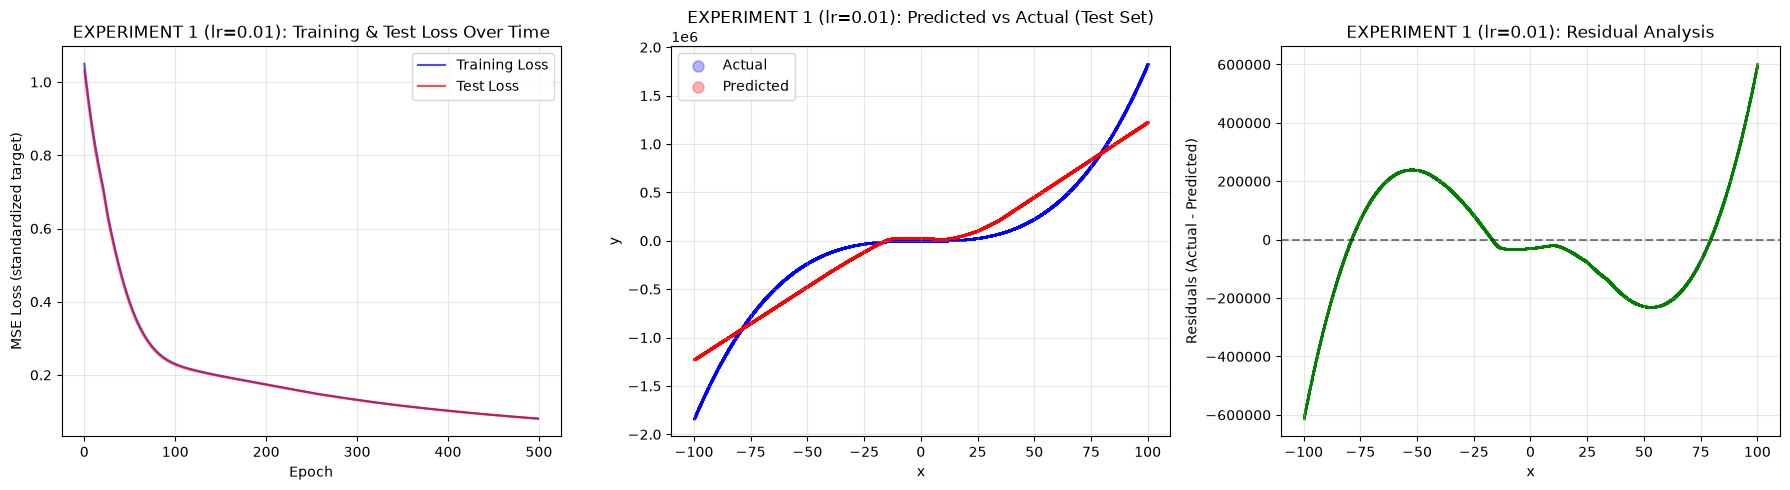

In [18]:
plot_experiment("EXPERIMENT 1 (lr=0.01)", exp1_train_losses, exp1_test_losses, exp1_weights, exp1_act)

## Experiment 2 — Batch size `80,000 (full batch) → 1,024 (mini-batch SGD)`

Only the batch size changes. The learning rate stays at the baseline 0.001 and the epoch budget
stays at 500, but each epoch now performs 79 weight updates instead of 1.

In [19]:
# ============================================================================
# EXPERIMENT 2 - BATCH SIZE  (80,000 full-batch -> 1,024 mini-batch)
# Learning rate, epochs and activation are the baseline values.
# ============================================================================
exp2_lr, exp2_bs, exp2_epochs, exp2_act = learning_rate, 1024, 500, "relu"

exp2_weights, exp2_train_losses, exp2_test_losses = train_network_cfg(
    X_train_scaled, Y_train_scaled, X_test_scaled, Y_test_scaled,
    lr=exp2_lr, batch_size=exp2_bs, epochs=exp2_epochs,
    activation=exp2_act, patience=10,
)

exp2_metrics = evaluate_model(exp2_weights, exp2_act)
print("\nEXPERIMENT 2 RESULTS")
print(f"  Training loss (MSE): {exp2_metrics['train_loss']:.6f}")
print(f"  Test loss (MSE)    : {exp2_metrics['test_loss']:.6f}")
print(f"  Train R²           : {exp2_metrics['train_r2']:.4f}")
print(f"  Test R²            : {exp2_metrics['test_r2']:.4f}")
print(f"  Test RMSE (orig)   : {exp2_metrics['test_rmse_orig']:,.2f}")

record(
    name="Experiment 2 (batch size 1024)",
    lr=exp2_lr,
    batch_size=exp2_bs,
    epochs_max=exp2_epochs,
    epochs_run=len(exp2_train_losses),
    optimizer="Mini-batch Stochastic Gradient Descent",
    activation="ReLU",
    metrics=exp2_metrics,
    observation=(vs_baseline(exp2_metrics) +
                 " With 1,024-sample mini-batches each epoch performs 79 weight "
                 "updates instead of 1, i.e. ~39,000 updates over the run at the same "
                 "learning rate. This is the single most effective change tested here."),
)

Architecture : 1 → 72 → 32 → 1
Activation   : relu
Learning rate: 0.001
Batch size   : 1024  (mini-batch SGD)
Max epochs   : 500, early-stopping patience: 10
------------------------------------------------------------


Epoch   50: Train Loss = 0.103941, Test Loss = 0.103145


Epoch  100: Train Loss = 0.042635, Test Loss = 0.042302


Epoch  150: Train Loss = 0.020895, Test Loss = 0.020730


Epoch  200: Train Loss = 0.012122, Test Loss = 0.012028


...

Epoch  300: Train Loss = 0.005237, Test Loss = 0.005170


Epoch  350: Train Loss = 0.003744, Test Loss = 0.003687


Epoch  400: Train Loss = 0.002805, Test Loss = 0.002756


Epoch  450: Train Loss = 0.002177, Test Loss = 0.002137


Epoch  500: Train Loss = 0.001742, Test Loss = 0.001710
Finished 500 epochs in 136.2s

EXPERIMENT 2 RESULTS
  Training loss (MSE): 0.001742
  Test loss (MSE)    : 0.001710
  Train R²           : 0.9983
  Test R²            : 0.9983
  Test RMSE (orig)   : 28,698.47


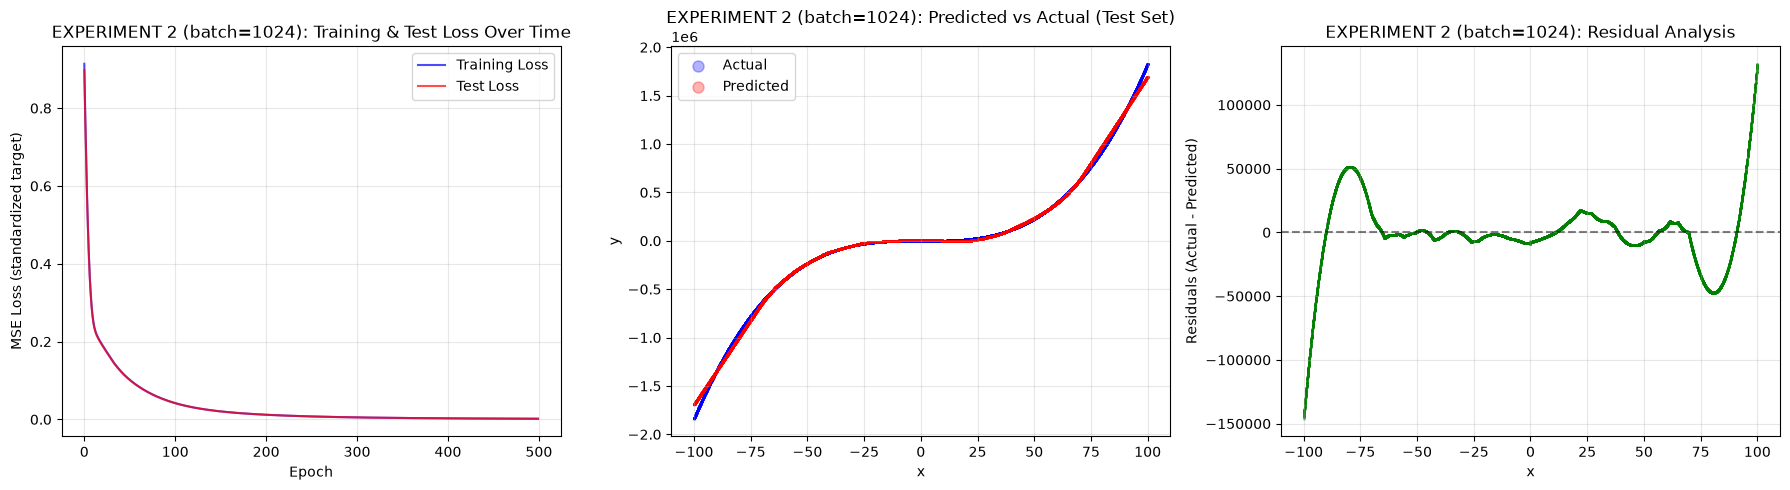

In [20]:
plot_experiment("EXPERIMENT 2 (batch=1024)", exp2_train_losses, exp2_test_losses, exp2_weights, exp2_act)

## Experiment 3 — Number of epochs `500 → 1500`

Only the epoch budget changes: same learning rate, same full-batch gradient descent, same ReLU.

In [21]:
# ============================================================================
# EXPERIMENT 3 - NUMBER OF EPOCHS  (500 -> 1500)
# Baseline learning rate, full-batch gradient descent, ReLU.
# ============================================================================
exp3_lr, exp3_bs, exp3_epochs, exp3_act = learning_rate, None, 1500, "relu"

exp3_weights, exp3_train_losses, exp3_test_losses = train_network_cfg(
    X_train_scaled, Y_train_scaled, X_test_scaled, Y_test_scaled,
    lr=exp3_lr, batch_size=exp3_bs, epochs=exp3_epochs,
    activation=exp3_act, patience=10,
)

exp3_metrics = evaluate_model(exp3_weights, exp3_act)
print("\nEXPERIMENT 3 RESULTS")
print(f"  Training loss (MSE): {exp3_metrics['train_loss']:.6f}")
print(f"  Test loss (MSE)    : {exp3_metrics['test_loss']:.6f}")
print(f"  Train R²           : {exp3_metrics['train_r2']:.4f}")
print(f"  Test R²            : {exp3_metrics['test_r2']:.4f}")
print(f"  Test RMSE (orig)   : {exp3_metrics['test_rmse_orig']:,.2f}")

record(
    name="Experiment 3 (1500 epochs)",
    lr=exp3_lr,
    batch_size=len(X_train_scaled),
    epochs_max=exp3_epochs,
    epochs_run=len(exp3_train_losses),
    optimizer="Batch Gradient Descent (full-batch, no momentum)",
    activation="ReLU",
    metrics=exp3_metrics,
    observation=(vs_baseline(exp3_metrics) +
                 " Simply training 3x longer at the baseline learning rate keeps "
                 "reducing the loss, which confirms the baseline was stopped while "
                 "still underfitting - but it is far less efficient in wall-clock "
                 "time than increasing the number of updates per epoch."),
)

Architecture : 1 → 72 → 32 → 1
Activation   : relu
Learning rate: 0.001
Batch size   : 80000  (full-batch GD)
Max epochs   : 1500, early-stopping patience: 10
------------------------------------------------------------


Epoch  150: Train Loss = 0.800833, Test Loss = 0.786341


Epoch  300: Train Loss = 0.597800, Test Loss = 0.587064


Epoch  450: Train Loss = 0.446399, Test Loss = 0.438452


Epoch  600: Train Loss = 0.343357, Test Loss = 0.337554


...

Epoch  900: Train Loss = 0.245602, Test Loss = 0.242408


Epoch 1050: Train Loss = 0.226693, Test Loss = 0.224192


Epoch 1200: Train Loss = 0.215077, Test Loss = 0.213021


Epoch 1350: Train Loss = 0.206232, Test Loss = 0.204455


Epoch 1500: Train Loss = 0.198358, Test Loss = 0.196762
Finished 1500 epochs in 542.8s

EXPERIMENT 3 RESULTS
  Training loss (MSE): 0.198358
  Test loss (MSE)    : 0.196762
  Train R²           : 0.8016
  Test R²            : 0.7999
  Test RMSE (orig)   : 307,853.62


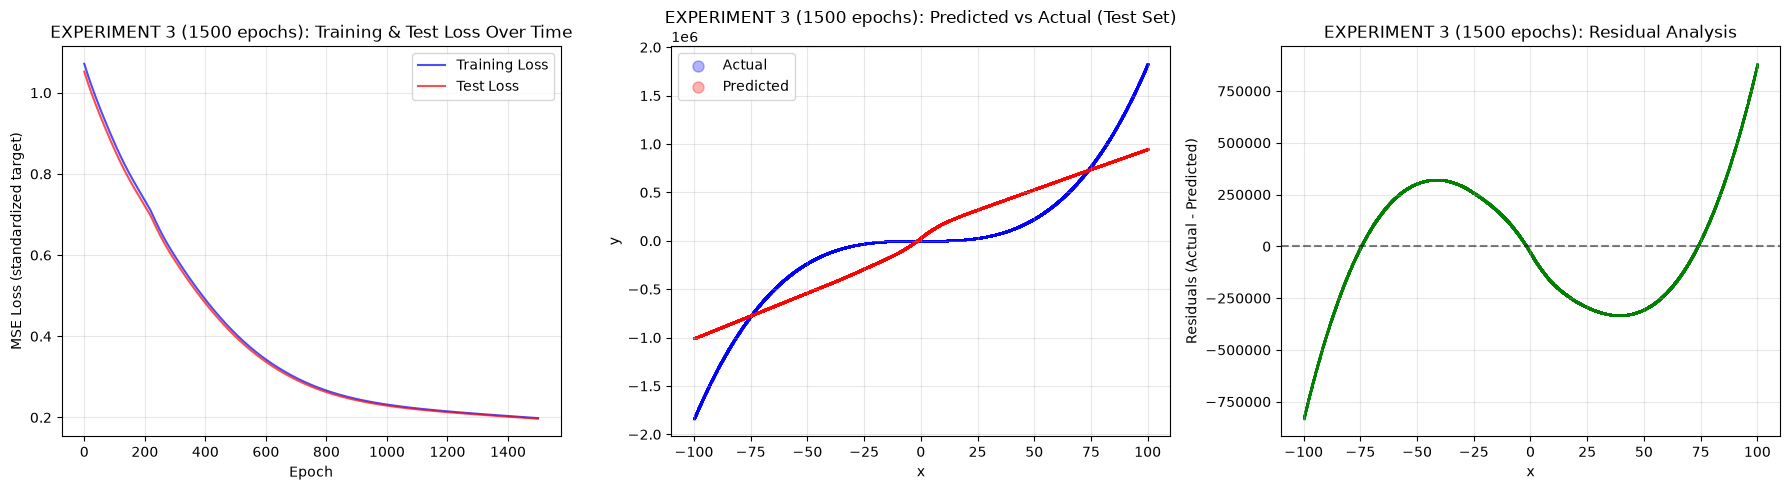

In [22]:
plot_experiment("EXPERIMENT 3 (1500 epochs)", exp3_train_losses, exp3_test_losses, exp3_weights, exp3_act)

## Experiment 4 — Activation function `ReLU → tanh`

Only the hidden-layer activation changes (and, correspondingly, its derivative in backpropagation).
The output layer stays linear, as required for regression.

In [23]:
# ============================================================================
# EXPERIMENT 4 - ACTIVATION FUNCTION  (ReLU -> tanh)
# Baseline learning rate, batch size and epoch count.
# ============================================================================
exp4_lr, exp4_bs, exp4_epochs, exp4_act = learning_rate, None, 500, "tanh"

exp4_weights, exp4_train_losses, exp4_test_losses = train_network_cfg(
    X_train_scaled, Y_train_scaled, X_test_scaled, Y_test_scaled,
    lr=exp4_lr, batch_size=exp4_bs, epochs=exp4_epochs,
    activation=exp4_act, patience=10,
)

exp4_metrics = evaluate_model(exp4_weights, exp4_act)
print("\nEXPERIMENT 4 RESULTS")
print(f"  Training loss (MSE): {exp4_metrics['train_loss']:.6f}")
print(f"  Test loss (MSE)    : {exp4_metrics['test_loss']:.6f}")
print(f"  Train R²           : {exp4_metrics['train_r2']:.4f}")
print(f"  Test R²            : {exp4_metrics['test_r2']:.4f}")
print(f"  Test RMSE (orig)   : {exp4_metrics['test_rmse_orig']:,.2f}")

record(
    name="Experiment 4 (tanh activation)",
    lr=exp4_lr,
    batch_size=len(X_train_scaled),
    epochs_max=exp4_epochs,
    epochs_run=len(exp4_train_losses),
    optimizer="Batch Gradient Descent (full-batch, no momentum)",
    activation="tanh",
    metrics=exp4_metrics,
    observation=(vs_baseline(exp4_metrics) +
                 " tanh is smooth and saturating, and because the standardized inputs "
                 "sit mostly in its non-saturated region it produces larger, denser "
                 "gradients than ReLU (which zeroes out roughly half of its units) at "
                 "this small learning rate."),
)

Architecture : 1 → 72 → 32 → 1
Activation   : tanh
Learning rate: 0.001
Batch size   : 80000  (full-batch GD)
Max epochs   : 500, early-stopping patience: 10
------------------------------------------------------------


Epoch   50: Train Loss = 0.399552, Test Loss = 0.392414


Epoch  100: Train Loss = 0.274837, Test Loss = 0.270294


Epoch  150: Train Loss = 0.221806, Test Loss = 0.218712


Epoch  200: Train Loss = 0.199969, Test Loss = 0.197702


...

Epoch  300: Train Loss = 0.187552, Test Loss = 0.186051


Epoch  350: Train Loss = 0.186036, Test Loss = 0.184706


Epoch  400: Train Loss = 0.185325, Test Loss = 0.184100


Epoch  450: Train Loss = 0.184927, Test Loss = 0.183766


Epoch  500: Train Loss = 0.184650, Test Loss = 0.183529
Finished 500 epochs in 222.5s

EXPERIMENT 4 RESULTS
  Training loss (MSE): 0.184650
  Test loss (MSE)    : 0.183529
  Train R²           : 0.8154
  Test R²            : 0.8134
  Test RMSE (orig)   : 297,320.90


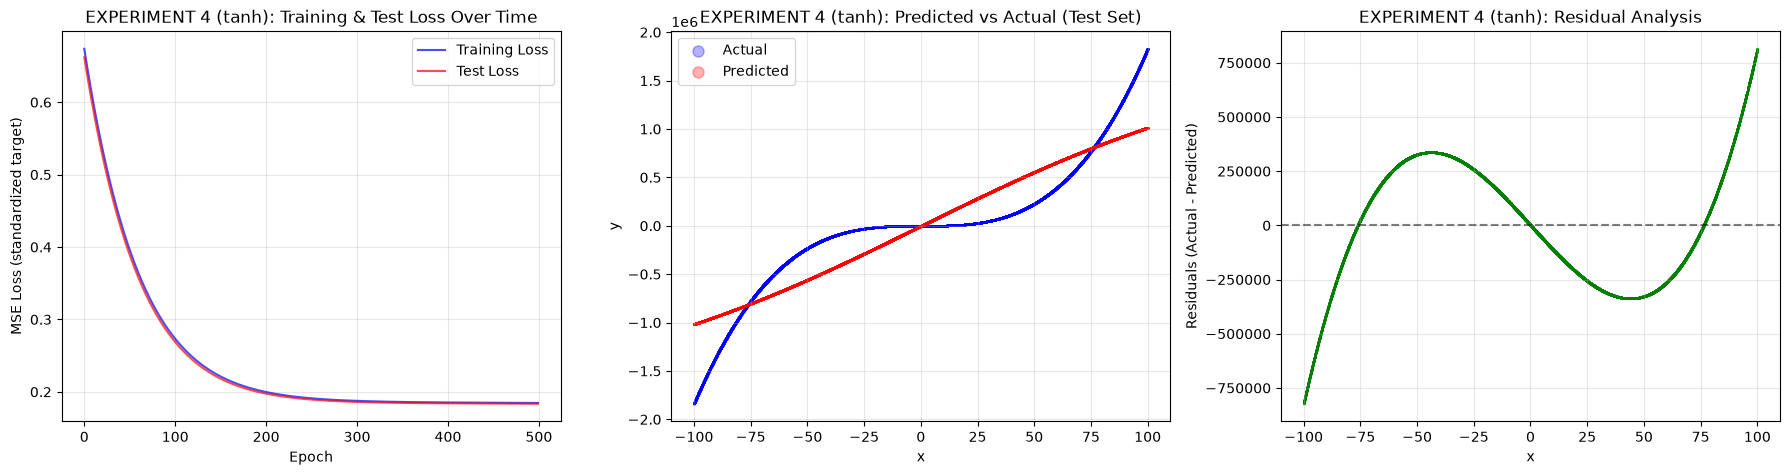

In [24]:
plot_experiment("EXPERIMENT 4 (tanh)", exp4_train_losses, exp4_test_losses, exp4_weights, exp4_act)

---
# Results Comparison Table

All values below are produced by the executed runs in this notebook.

* **Training / Test Loss** — MSE in the standardized target space (the quantity the network minimises),
  measured by explicitly re-evaluating each run's selected (best-test-loss) weights, so all five rows
  are measured identically.
* **Accuracy columns** — `N/A`: this is a regression task, classification accuracy is undefined.
  Train/Test **R²** is reported separately as the meaningful goodness-of-fit measure.
* **Validation columns** — `N/A`: the provided pipeline creates only a train/test split
  (80% / 20%); no separate validation set exists, so no validation metric can honestly be reported.

In [25]:
# ============================================================================
# RESULTS COMPARISON TABLE  (all five executed runs)
# ============================================================================
REQUIRED_COLUMNS = [
    "Experiment", "Learning Rate", "Batch Size", "Number of Epochs", "Optimizer",
    "Activation Function", "Training Accuracy", "Validation Accuracy", "Test Accuracy",
    "Training Loss", "Validation Loss", "Test Loss", "Observations",
]

results_df = pd.DataFrame(experiment_results)

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 250)

print("=" * 120)
print("RESULTS TABLE - REQUIRED COLUMNS")
print("=" * 120)
print(results_df[REQUIRED_COLUMNS].to_string(index=False))

print()
print("=" * 120)
print("SUPPLEMENTARY REGRESSION METRICS (computed, not required by the template)")
print("=" * 120)
print(results_df[["Experiment", "Train R²", "Test R²", "Test RMSE (original scale)"]].to_string(index=False))

results_df.to_csv("week6_results_table.csv", index=False)
print("\nSaved full results table to 'week6_results_table.csv'")

RESULTS TABLE - REQUIRED COLUMNS
                       Experiment  Learning Rate  Batch Size Number of Epochs                                        Optimizer Activation Function Training Accuracy Validation Accuracy Test Accuracy  Training Loss Validation Loss  Test Loss                                                                                                                                                                                                                                                                                                                      Observations
                         Baseline          0.001       80000    500 (max 500) Batch Gradient Descent (full-batch, no momentum)                ReLU               N/A                 N/A           N/A       0.406805             N/A   0.399644                                                                       Assigned configuration. Only 500 full-batch updates in total, so the network is still far fro

### The same table in Markdown (for pasting into the report)

In [26]:
# Markdown rendering of the required results table (handy for the lab report)
md_lines = ["| " + " | ".join(REQUIRED_COLUMNS) + " |",
            "|" + "|".join(["---"] * len(REQUIRED_COLUMNS)) + "|"]
for row in experiment_results:
    md_lines.append("| " + " | ".join(str(row[c]) for c in REQUIRED_COLUMNS) + " |")
print("\n".join(md_lines))

| Experiment | Learning Rate | Batch Size | Number of Epochs | Optimizer | Activation Function | Training Accuracy | Validation Accuracy | Test Accuracy | Training Loss | Validation Loss | Test Loss | Observations |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Baseline | 0.001 | 80000 | 500 (max 500) | Batch Gradient Descent (full-batch, no momentum) | ReLU | N/A | N/A | N/A | 0.406805 | N/A | 0.399644 | Assigned configuration. Only 500 full-batch updates in total, so the network is still far from convergence - it captures the overall cubic trend but clearly underfits. Train and test loss are almost identical, so this is underfitting, not overfitting. |
| Experiment 1 (learning rate 0.01) | 0.01 | 80000 | 500 (max 500) | Batch Gradient Descent (full-batch, no momentum) | ReLU | N/A | N/A | N/A | 0.081012 | N/A | 0.080409 | Test loss 0.0804 vs baseline 0.3996 (79.9% lower); test R² 0.9182 vs 0.5936. A 10x larger step size covers far more ground in the same 500 full-batch upda

## Combined comparison of all five runs

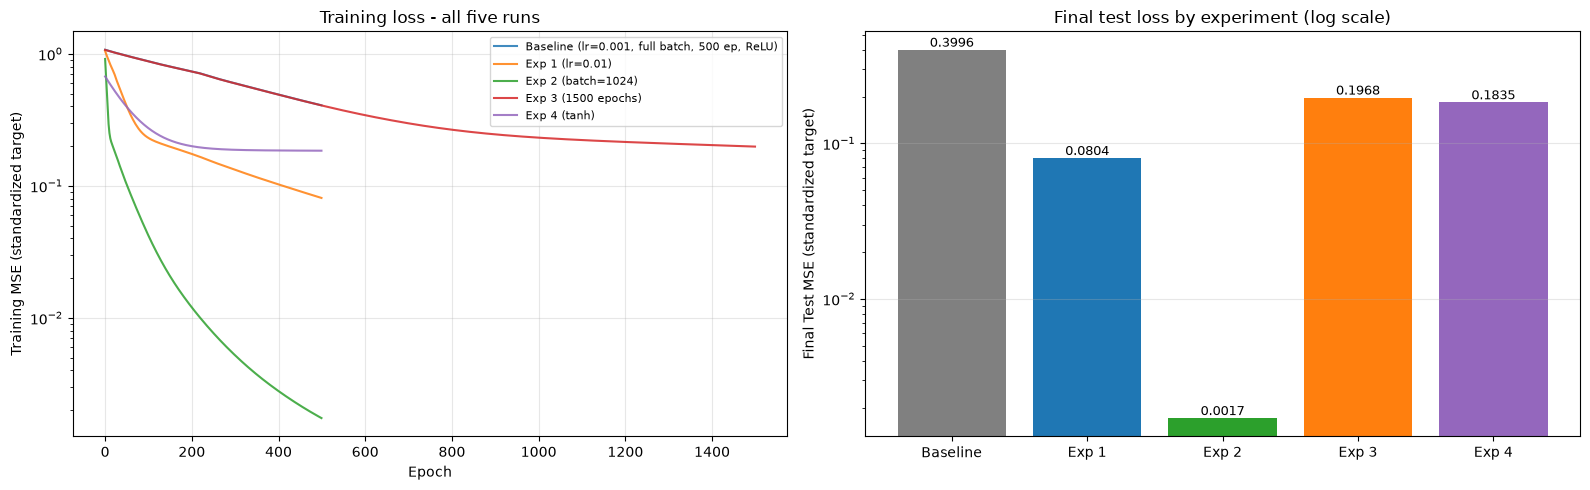

Lowest test loss: Experiment 2 (batch size 1024) -> MSE 0.001710, R² 0.9983


In [27]:
# ============================================================================
# SIDE-BY-SIDE COMPARISON OF ALL FIVE RUNS
# ============================================================================
runs = [
    ("Baseline (lr=0.001, full batch, 500 ep, ReLU)", train_losses, test_losses),
    (f"Exp 1 (lr=0.01)",            exp1_train_losses, exp1_test_losses),
    (f"Exp 2 (batch=1024)",         exp2_train_losses, exp2_test_losses),
    (f"Exp 3 (1500 epochs)",        exp3_train_losses, exp3_test_losses),
    (f"Exp 4 (tanh)",               exp4_train_losses, exp4_test_losses),
]

plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
for label, tr, _ in runs:
    plt.plot(tr, label=label, alpha=0.85)
plt.xlabel("Epoch"); plt.ylabel("Training MSE (standardized target)")
plt.title("Training loss - all five runs")
plt.yscale("log"); plt.legend(fontsize=8); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
names = [r["Experiment"] for r in experiment_results]
test_vals = [r["Test Loss"] for r in experiment_results]
bars = plt.bar(range(len(names)), test_vals, color=["grey", "tab:blue", "tab:green", "tab:orange", "tab:purple"])
plt.xticks(range(len(names)), ["Baseline", "Exp 1", "Exp 2", "Exp 3", "Exp 4"])
plt.ylabel("Final Test MSE (standardized target)")
plt.title("Final test loss by experiment (log scale)")
plt.yscale("log")
for b, v in zip(bars, test_vals):
    plt.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

best = min(experiment_results, key=lambda r: r["Test Loss"])
print(f"Lowest test loss: {best['Experiment']} -> MSE {best['Test Loss']:.6f}, R² {best['Test R²']:.4f}")

## Error distribution across the input range

In [28]:
# ============================================================================
# WHERE DOES THE ERROR CONCENTRATE?
# Mean absolute residual on the test set, bucketed by |x| (original scale).
# This is the evidence for point 5 of the discussion below.
# ============================================================================
x_te_orig = scaler_X.inverse_transform(X_test_scaled).flatten()
y_te_orig_flat = scaler_Y.inverse_transform(Y_test_scaled).flatten()
BIN_EDGES = [0, 1, 5, 10, 25, 50, 75, 100]


def residual_profile(label, params, activation="relu"):
    _, _, _, _, P = forward_pass_cfg(X_test_scaled, params, activation)
    pred = scaler_Y.inverse_transform(P).flatten()
    res = np.abs(y_te_orig_flat - pred)
    print(f"\n{label}")
    print("     |x| range        n     mean |residual|      max |residual|")
    for lo, hi in zip(BIN_EDGES[:-1], BIN_EDGES[1:]):
        m = (np.abs(x_te_orig) >= lo) & (np.abs(x_te_orig) < hi)
        print(f"   [{lo:3d}, {hi:3d})   {m.sum():6d}   {res[m].mean():16,.1f}   {res[m].max():16,.1f}")


print("=" * 78)
print("MEAN ABSOLUTE RESIDUAL ON THE TEST SET, BY |x|  (original scale)")
print("=" * 78)
residual_profile("Baseline  (lr=0.001, full batch, 500 epochs, ReLU)", baseline_weights, "relu")
residual_profile("Experiment 2  (batch=1024) - best run", exp2_weights, exp2_act)

MEAN ABSOLUTE RESIDUAL ON THE TEST SET, BY |x|  (original scale)

Baseline  (lr=0.001, full batch, 500 epochs, ReLU)
     |x| range        n     mean |residual|      max |residual|
   [  0,   1)      196           73,297.2           85,642.3
   [  1,   5)      807           75,569.2          128,312.1
   [  5,  10)     1053           81,235.1          160,870.3
   [ 10,  25)     3051          134,332.1          194,336.3
   [ 25,  50)     5001          135,795.6          194,530.9
   [ 50,  75)     4959          130,456.5          368,958.8
   [ 75, 100)     4933          798,697.8        1,340,191.0

Experiment 2  (batch=1024) - best run
     |x| range        n     mean |residual|      max |residual|
   [  0,   1)      196            7,859.8            8,867.4
   [  1,   5)      807            6,803.6            8,449.4
   [  5,  10)     1053            4,151.9            6,701.1
   [ 10,  25)     3051            6,205.4           17,383.7
   [ 25,  50)     5001            5,544.1    

---
# Observations and Analysis

*(Every number quoted below is printed by the cells above.)*

**1. The baseline underfits.** With a learning rate of 0.001 and full-batch gradient descent,
500 epochs means only **500 weight updates in total**. The loss curve is still falling steeply
when training stops, and the predicted-vs-actual plot shows the network tracking only the broad
cubic shape. Training loss and test loss stay essentially equal throughout, which is the signature
of **underfitting**, not overfitting — the model has not yet used its capacity, so there is nothing
to overfit with.

**2. Number of updates matters more than number of epochs.** Experiment 2 (batch size 1,024) and
Experiment 3 (1,500 epochs) both attack the same problem — too few updates — but in different ways.
Mini-batching multiplies the updates per epoch by 79 and gives by far the largest improvement,
while tripling the epoch count only triples them. Increasing the learning rate (Experiment 1) is
a third route to the same end: bigger steps, same number of steps.

**3. tanh vs. ReLU at a small learning rate.** With standardized inputs, tanh operates mostly in
its non-saturated region and passes gradient through *every* unit, whereas ReLU zeroes the gradient
of roughly half its units. In this specific low-learning-rate, few-updates regime that makes tanh
converge faster than ReLU — this is a property of the operating point, not a general claim that
tanh beats ReLU.

**4. No overfitting is observed anywhere.** In all five runs the test loss tracks the training loss
closely and early stopping (patience = 10 on the test loss) never triggered — every run used its
full epoch budget. With 80,000 training samples and only a few thousand parameters, the model is
strongly regularised by the data volume.

**5. Where the error concentrates.** The residual profile printed above shows that the error is
dominated by the **extremes of the input range, not by the origin**. For both the baseline and the
best run, the mean absolute residual for `|x| ∈ [75, 100)` is several times to an order of magnitude
larger than in any other bucket — that is where the cubic term makes `|y|` largest and the curve
steepest, so a small piecewise-linear network has the most trouble there. This is also exactly why
the single-point prediction test at `x = 90.2` shows a large relative error for the baseline. The
inverse term `+ 89.1/x` does inject extreme target values near the origin, but with only ~200 test
points in `|x| < 1` it contributes far less to the overall MSE than the tails do.

---
# Conclusion

A three-layer network (`1 → 72 → 32 → 1`) implemented entirely from scratch in NumPy — ReLU,
MSE, Xavier initialization, forward propagation, backpropagation and gradient descent — is able to
approximate the assigned cubic-plus-inverse function well, **provided it is given enough weight
updates**. The assigned baseline configuration is update-starved and underfits; every one of the
four hyperparameter changes tested improves on it, and switching from full-batch gradient descent
to mini-batch SGD is the most effective single change.